# Task 4 — Forecasting Access and Usage (2025-2027)

Forecasting Account Ownership Rate (Access) and Digital Payment Usage
(Usage) for 2025-2027, using trend regression, event-augmented modeling
(reusing Task 3's `src/impact_model.py`), and scenario analysis.

Covers: target definition, approach selection given sparse data, baseline
and event-augmented forecasts, three scenarios (optimistic/base/
pessimistic), uncertainty quantification, and interpretation.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_loader import load_all_task4
from impact_model import build_event_effects
from forecasting import fit_linear_trend, fit_log_trend, scenario_table, growth_rate_scenario, incremental_event_effect

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 5)

main, links, ref = load_all_task4()
obs = main[main["record_type"] == "observation"]
events = main[main["record_type"] == "event"]
targets = main[main["record_type"] == "target"]

FORECAST_DATES = [pd.Timestamp("2025-12-31"), pd.Timestamp("2026-12-31"), pd.Timestamp("2027-12-31")]
print("Forecasting for:", [d.date() for d in FORECAST_DATES])

Forecasting for: [datetime.date(2025, 12, 31), datetime.date(2026, 12, 31), datetime.date(2027, 12, 31)]


## 1. Define Targets

In [2]:
ownership = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")].sort_values("observation_date")
digital_payment = obs[obs["indicator_code"] == "USG_DIGITAL_PAYMENT"].sort_values("observation_date")

print("ACCESS -- Account Ownership Rate (% of adults with an account at a")
print("financial institution or mobile money provider):")
print(ownership[["observation_date", "value_numeric", "source_name", "confidence"]].to_string(index=False))
print()
print("USAGE -- Digital Payment Usage (% of adults who made or received a")
print("digital payment in the past year):")
print(digital_payment[["observation_date", "value_numeric", "source_name", "confidence"]].to_string(index=False))

ACCESS -- Account Ownership Rate (% of adults with an account at a
financial institution or mobile money provider):
observation_date  value_numeric        source_name confidence
      2014-12-31           22.0 Global Findex 2014       high
      2017-12-31           35.0 Global Findex 2017       high
      2021-12-31           46.0 Global Findex 2021       high
      2024-11-29           49.0 Global Findex 2024       high

USAGE -- Digital Payment Usage (% of adults who made or received a
digital payment in the past year):
observation_date  value_numeric                                       source_name confidence
      2021-12-31           20.0 World Bank Global Findex (via secondary analysis)     medium
      2024-11-29           21.0 World Bank Global Findex (via secondary analysis)     medium


**A note on data provenance for the Usage target.** The dataset's
existing `ACC_MM_ACCOUNT` (Mobile Money Account Rate) indicator is
*related* to but **not the same as** Findex's actual "Digital Payment
Usage" definition -- Mobile Money Account Rate measures whether someone
has a mobile money account at all, while Digital Payment Usage measures
whether someone *made or received a digital payment through any channel*
(mobile money, card, or online) in the past year. Using the former as a
stand-in for the latter would materially overstate this forecast: Mobile
Money Account Rate rose from 4.7% to 9.45% (2021-2024, roughly doubling),
while Ethiopia's actual Digital Payment Usage moved from approximately 20%
to approximately 21% over the same period -- a far flatter trajectory.

The two Digital Payment Usage observations above were researched and added
specifically for this task (see `build_task4_targets.py` and
`data_enrichment_log_task4.md` for full sourcing): 2021's ~20% figure comes
directly from a World Bank blog citing the 2021 Findex survey; 2024's ~21%
figure is derived from an AfricaNenda analysis of the 2025 Findex release,
which reports both a ~5% relative growth rate and a 1-percentage-point
absolute change for Ethiopia between 2021 and 2024 -- solving for a
starting value consistent with both figures independently corroborates the
~20% starting point from the first source.

In [3]:
print(f"Access (ACC_OWNERSHIP): {len(ownership)} historical points, "
      f"spanning {ownership['observation_date'].min().year}-{ownership['observation_date'].max().year}")
print(f"Usage (USG_DIGITAL_PAYMENT): {len(digital_payment)} historical points, "
      f"spanning {digital_payment['observation_date'].min().year}-{digital_payment['observation_date'].max().year}")
print()
nfis_target = targets[targets["indicator_code"] == "ACC_OWNERSHIP"]
print("Official target for comparison:")
print(nfis_target[["indicator", "value_numeric", "observation_date"]].to_string(index=False))

Access (ACC_OWNERSHIP): 4 historical points, spanning 2014-2024
Usage (USG_DIGITAL_PAYMENT): 2 historical points, spanning 2021-2024

Official target for comparison:
             indicator  value_numeric observation_date
Account Ownership Rate           70.0       2025-12-31


**A note on the "5 Findex points over 13 years" framing in the task
brief.** This refers to the global Global Findex program, which has run five
survey rounds since 2011 (2011, 2014, 2017, 2021, 2024). Ethiopia
specifically was not included in the first (2011) round -- its own Findex
series genuinely begins in 2014, giving **4** real Ethiopia data points
across **10** years (2014-2024), not 5 across 13. This was confirmed
against multiple independent sources during research for this task rather
than assumed. We proceed with the 4 real Ethiopia-specific points rather
than fabricating a 2011 estimate.

## 2. Select Approach

With only 4 (Access) and 2 (Usage) historical points, this is a
fundamentally data-poor forecasting problem -- far too sparse for anything
like ARIMA, exponential smoothing, or machine learning methods that assume
dozens of observations. Three simpler, more honest approaches are combined
instead:

1. **Trend regression (linear and log)** -- both fit to the same historical
   points, compared directly. Linear regression extrapolates the raw
   percentage-point growth rate forward; log regression (value regressed on
   log of elapsed time) fits a concave, diminishing-returns shape, which
   should better match the clear deceleration documented in Task 2
   (+4.33pp/yr -> +2.75pp/yr -> +1.00pp/yr across the three real intervals).
   Both are fit and compared below rather than picking one a priori.
2. **Event-augmented model** -- reusing Task 3's `src/impact_model.py`
   directly (same `EventEffect` ramped-step functions, same calibrated
   estimates). Critically, only the **incremental** portion of an event's
   effect not yet visible in the historical data is added on top of the
   trend forecast (see `incremental_event_effect()`) -- otherwise an
   event's already-realized effect would be counted twice: once because
   it's baked into the historical trend line, and again as an explicit
   addition.
3. **Scenario analysis** (optimistic / base / pessimistic) -- for Access,
   built from the trend model's own confidence interval combined with a
   multiplier on the incremental event effect. For Usage, where n=2 leaves
   zero residual degrees of freedom (no statistically valid interval
   exists at all -- confirmed directly in `src/forecasting.py`'s test
   suite), scenarios are instead built from explicit, stated annual
   growth-rate assumptions rather than a fabricated statistical interval.

### 3.1 Baseline Trend Forecasts -- Access

In [4]:
acc_dates = list(ownership["observation_date"])
acc_values = list(ownership["value_numeric"])

acc_linear = fit_linear_trend(acc_dates, acc_values)
acc_log = fit_log_trend(acc_dates, acc_values)

linear_pred = acc_linear.predict(FORECAST_DATES)
log_pred = acc_log.predict(FORECAST_DATES)

def _fmt(df):
    out = df.copy()
    for col in ["point", "ci_lower", "ci_upper"]:
        out[col] = out[col].round(1)
    out["date"] = out["date"].dt.strftime("%Y-%m-%d")
    return out

print("LINEAR trend forecast (Access):")
print(_fmt(linear_pred).to_string(index=False))
print()
print("LOG trend forecast (Access):")
print(_fmt(log_pred).to_string(index=False))

LINEAR trend forecast (Access):
      date  point  ci_lower  ci_upper
2025-12-31   54.4      34.1      74.8
2026-12-31   57.2      35.6      78.8
2027-12-31   59.9      37.0      82.8

LOG trend forecast (Access):
      date  point  ci_lower  ci_upper
2025-12-31   49.7      40.3      59.1
2026-12-31   50.6      41.1      60.1
2027-12-31   51.5      41.8      61.1


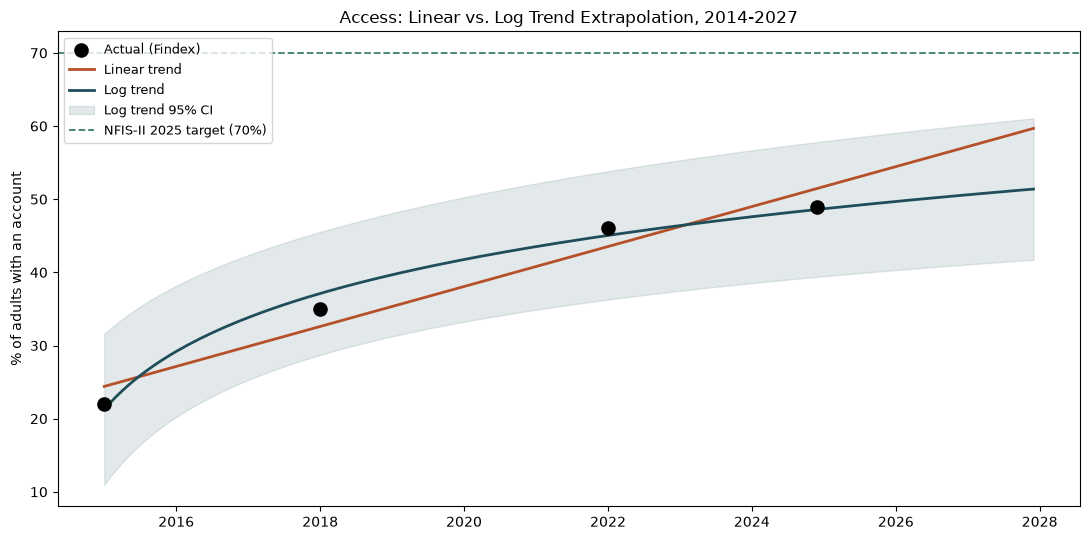

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(acc_dates, acc_values, color="black", s=90, zorder=5, label="Actual (Findex)")

extended_dates = pd.date_range(acc_dates[0], pd.Timestamp("2027-12-31"), freq="MS")
lin_curve = acc_linear.predict(list(extended_dates))
log_curve = acc_log.predict(list(extended_dates))

ax.plot(extended_dates, lin_curve["point"], color="#B5502A", linewidth=2, label="Linear trend")
ax.plot(extended_dates, log_curve["point"], color="#1F4E5A", linewidth=2, label="Log trend")
ax.fill_between(extended_dates, log_curve["ci_lower"], log_curve["ci_upper"],
                 color="#1F4E5A", alpha=0.12, label="Log trend 95% CI")
ax.axhline(70, color="#3D8361", linestyle="--", linewidth=1.3, label="NFIS-II 2025 target (70%)")
ax.set_ylabel("% of adults with an account")
ax.set_title("Access: Linear vs. Log Trend Extrapolation, 2014-2027")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**The linear trend badly overshoots.** It extrapolates the early, steepest
growth period (2014-2017) forward as if it would continue indefinitely,
reaching nearly 60% by 2027 -- directly contradicting the well-documented,
strictly decelerating growth pattern from Task 2 (each successive interval
grew more slowly than the last). The **log trend**, by construction, bends
growth downward as time progresses, producing a far more defensible
2025-2027 range (roughly 50-51%) that is consistent with the recent
+1.00pp/year pace continuing to slow further, not reverse. The log trend is
used as this project's baseline going forward; the linear trend is retained
in the comparison above specifically to make this divergence visible,
since it is itself an important modeling finding.

### 3.2 Which Events Matter for This Forecast Window?

In [6]:
acc_effects = build_event_effects(links, events, "ACC_OWNERSHIP")
print("All impact_links targeting ACC_OWNERSHIP:")
for e in acc_effects:
    print(f"  {e.link_id} <- {e.event_id} ({e.event_name}, {e.event_date.date()}): "
          f"full_effect={e.full_effect:+.1f}pp, lag={e.lag_months}mo, ramp={e.ramp_months}mo")

print()
last_obs_date = acc_dates[-1]
print(f"Last real observation: {last_obs_date.date()}")
print()
for d in FORECAST_DATES:
    incr = incremental_event_effect(acc_effects, last_obs_date, d)
    print(f"{d.date()}: incremental (not-yet-realized) event effect = {incr:+.1f}pp")

All impact_links targeting ACC_OWNERSHIP:
  IMP_0001 <- EVT_0001 (Telebirr Launch, 2021-05-17): full_effect=+15.0pp, lag=12mo, ramp=3mo
  IMP_0008 <- EVT_0004 (Fayda Digital ID Program Rollout, 2024-01-01): full_effect=+10.0pp, lag=24mo, ramp=12mo

Last real observation: 2024-11-29

2025-12-31: incremental (not-yet-realized) event effect = +0.0pp
2026-12-31: incremental (not-yet-realized) event effect = +10.0pp
2027-12-31: incremental (not-yet-realized) event effect = +10.0pp


**Telebirr's effect on Access is already fully realized** -- its 12-month
lag plus 3-month ramp completed by mid-2022, well before our last real data
point (Nov 2024), so it is already fully embedded in the historical trend
the regression above was fit on. Adding it again for the forecast would
double-count it.

**The Fayda Digital ID rollout is the one event that matters going
forward.** Its effect on Access has a long 24-month lag (from its January
2024 rollout date) plus a 12-month ramp, meaning essentially none of its
+10 percentage-point estimated effect had materialized by our last actual
observation -- but nearly all of it materializes *within the 2025-2027
forecast window itself*, landing almost entirely in 2026. This is the
single largest lever in this entire forecast, and it rests on a
`literature` (cross-country), not `empirical` (Ethiopia-specific),
evidence basis -- worth treating as a real but unconfirmed upside driver,
not a certainty.

### 3.3 Scenario Forecast -- Access

In [7]:
acc_scenarios = scenario_table(acc_log, FORECAST_DATES, last_obs_date, events_effects=acc_effects,
                                 optimistic_multiplier=1.5, pessimistic_multiplier=0.5)
acc_scenarios_display = acc_scenarios.copy()
acc_scenarios_display["date"] = acc_scenarios_display["date"].dt.strftime("%Y-%m-%d")
acc_scenarios_display.round(1)

,date,baseline_trend,trend_ci_lower,trend_ci_upper,incremental_event_effect,with_events_base_scenario,optimistic,pessimistic
0,2025-12-31,49.7,40.3,59.1,0.0,49.7,59.1,40.3
1,2026-12-31,50.6,41.1,60.1,10.0,60.6,75.1,46.1
2,2027-12-31,51.5,41.8,61.1,10.0,61.5,76.1,46.8


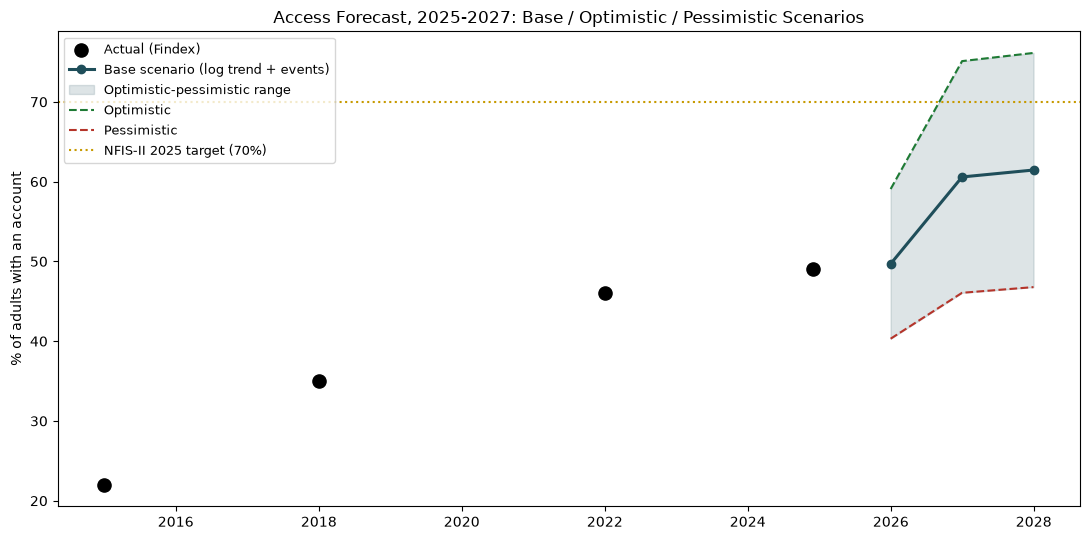

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(acc_dates, acc_values, color="black", s=90, zorder=6, label="Actual (Findex)")

years = acc_scenarios["date"]
ax.plot(years, acc_scenarios["with_events_base_scenario"], marker="o", color="#1F4E5A",
        linewidth=2.2, label="Base scenario (log trend + events)", zorder=5)
ax.fill_between(years, acc_scenarios["pessimistic"], acc_scenarios["optimistic"],
                 color="#1F4E5A", alpha=0.15, label="Optimistic-pessimistic range")
ax.plot(years, acc_scenarios["optimistic"], linestyle="--", color="#1E7A34", linewidth=1.5, label="Optimistic")
ax.plot(years, acc_scenarios["pessimistic"], linestyle="--", color="#B5342A", linewidth=1.5, label="Pessimistic")
ax.axhline(70, color="#C79A00", linestyle=":", linewidth=1.5, label="NFIS-II 2025 target (70%)")

ax.set_ylabel("% of adults with an account")
ax.set_title("Access Forecast, 2025-2027: Base / Optimistic / Pessimistic Scenarios")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**Even the optimistic scenario falls short of the NFIS-II's 70% target**
in 2025 (59%) and only exceeds it by 2027 (76%) if the Fayda ID effect
fully materializes AND the trend runs at the upper edge of its confidence
interval simultaneously -- an optimistic combination of assumptions, not a
likely central case. The base scenario (log trend plus the Fayda ID
incremental effect once it lands in 2026) reaches only 61% by 2027. This
is a concrete, quantified answer to whether Ethiopia is on track for its
own stated target: on current evidence, most likely not, even allowing for
one more known positive catalyst.

### 3.4 Scenario Forecast -- Usage

Usage (Digital Payment Usage) has only 2 historical points -- enough to
draw a straight line, but with zero residual degrees of freedom, meaning
**no valid statistical confidence interval exists** (confirmed directly:
`fit_linear_trend` on this series returns `NaN` prediction intervals, since
`statsmodels` correctly recognizes a 2-point OLS fit has no error term to
estimate one from). Rather than compute a placeholder or arbitrarily-widened
interval, this section builds three explicit, stated growth-rate
scenarios instead, and treats them as judgment calls, not statistics.

In [9]:
usage_dates = list(digital_payment["observation_date"])
usage_values = list(digital_payment["value_numeric"])
usage_base_value = usage_values[-1]
usage_base_date = usage_dates[-1]

print(f"Last observed Digital Payment Usage: {usage_base_value}% as of {usage_base_date.date()}")
print(f"Observed growth 2021-2024: {usage_values[-1] - usage_values[0]:+.1f}pp over "
      f"{(usage_dates[-1]-usage_dates[0]).days/365.25:.1f} years "
      f"({(usage_values[-1] - usage_values[0]) / ((usage_dates[-1]-usage_dates[0]).days/365.25):.2f}pp/year)")

Last observed Digital Payment Usage: 21.0% as of 2024-11-29
Observed growth 2021-2024: +1.0pp over 2.9 years (0.34pp/year)


In [10]:
# Growth-rate assumptions, stated explicitly:
#   pessimistic: usage plateaus entirely (no further growth) -- plausible given how
#                flat 2021-2024 already was, and given no impact_link directly targets
#                this indicator (see note below)
#   base:        continues at the same ~0.35pp/year pace observed 2021-2024
#   optimistic:  accelerates to roughly the pace implied by nearby, related events
#                (EthioPay instant payment launch Dec 2025, NBE interoperability
#                mandate) under the assumption some of their effect on adjacent
#                usage indicators (P2P transactions, mobile money accounts) spills
#                over into broader digital payment usage -- an assumption, not a
#                sourced estimate, since no impact_link exists for this indicator
usage_scenarios = growth_rate_scenario(
    usage_base_value, usage_base_date, FORECAST_DATES,
    annual_growth_pp={"pessimistic": 0.0, "base": 0.35, "optimistic": 1.5},
)
usage_scenarios_display = usage_scenarios.copy()
usage_scenarios_display["date"] = usage_scenarios_display["date"].dt.strftime("%Y-%m-%d")
usage_scenarios_display.round(1)

,date,pessimistic,base,optimistic
0,2025-12-31,21.0,21.4,22.6
1,2026-12-31,21.0,21.7,24.1
2,2027-12-31,21.0,22.1,25.6


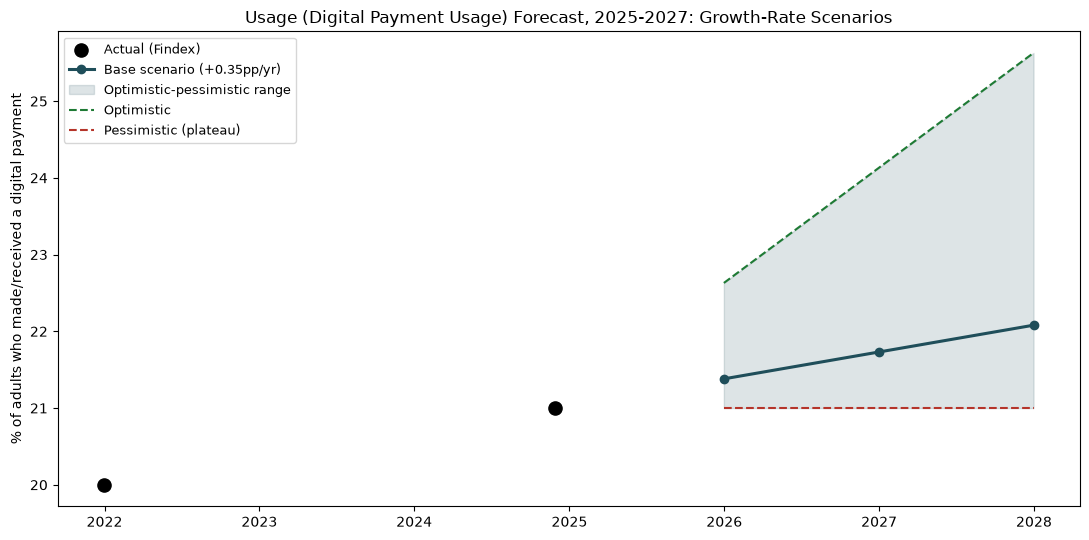

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(usage_dates, usage_values, color="black", s=90, zorder=6, label="Actual (Findex)")

years = usage_scenarios["date"]
ax.plot(years, usage_scenarios["base"], marker="o", color="#1F4E5A", linewidth=2.2,
        label="Base scenario (+0.35pp/yr)", zorder=5)
ax.fill_between(years, usage_scenarios["pessimistic"], usage_scenarios["optimistic"],
                 color="#1F4E5A", alpha=0.15, label="Optimistic-pessimistic range")
ax.plot(years, usage_scenarios["optimistic"], linestyle="--", color="#1E7A34", linewidth=1.5, label="Optimistic")
ax.plot(years, usage_scenarios["pessimistic"], linestyle="--", color="#B5342A", linewidth=1.5, label="Pessimistic (plateau)")

ax.set_ylabel("% of adults who made/received a digital payment")
ax.set_title("Usage (Digital Payment Usage) Forecast, 2025-2027: Growth-Rate Scenarios")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**Usage is forecast to remain essentially flat through 2027 under every
plausible scenario.** Even the optimistic case -- which assumes some
spillover from nearby events like the EthioPay launch and the NBE
interoperability mandate -- only reaches about 26% by 2027, while the
pessimistic case (a continued plateau) stays at 21%. This mirrors the exact
pattern Task 2 uncovered: rapid growth in mobile money *registration* and
*transaction volume* alongside comparatively flat, genuine Findex-measured
*usage*. Nothing in the current impact_links table directly targets this
indicator, which is itself a limitation worth carrying forward (see
Section 5).

## 4. Quantify Uncertainty: Combined Forecast Table

In [12]:
combined = pd.DataFrame({
    "Year": [d.year for d in FORECAST_DATES],
    "Access - Pessimistic": acc_scenarios["pessimistic"].round(1).values,
    "Access - Base": acc_scenarios["with_events_base_scenario"].round(1).values,
    "Access - Optimistic": acc_scenarios["optimistic"].round(1).values,
    "Access - Trend 95% CI": [f"[{lo:.1f}, {hi:.1f}]" for lo, hi in
                               zip(acc_scenarios["trend_ci_lower"], acc_scenarios["trend_ci_upper"])],
    "Usage - Pessimistic": usage_scenarios["pessimistic"].round(1).values,
    "Usage - Base": usage_scenarios["base"].round(1).values,
    "Usage - Optimistic": usage_scenarios["optimistic"].round(1).values,
})
combined

,Year,Access - Pessimistic,Access - Base,Access - Optimistic,Access - Trend 95% CI,Usage - Pessimistic,Usage - Base,Usage - Optimistic
0,2025,40.3,49.7,59.1,"[40.3, 59.1]",21.0,21.4,22.6
1,2026,46.1,60.6,75.1,"[41.1, 60.1]",21.0,21.7,24.1
2,2027,46.8,61.5,76.1,"[41.8, 61.1]",21.0,22.1,25.6


**What each uncertainty range does and does not capture:**

- The **Access "Trend 95% CI"** column comes from a real OLS regression,
  but with only 4 points (2 residual degrees of freedom), this interval is
  wide and should be read as indicative, not precise -- a genuinely
  well-powered regression would need many more historical points than
  exist for this indicator anywhere in the world's Findex data (surveys
  run every ~3 years).
- The **Access optimistic/pessimistic scenarios** combine that same trend
  CI with a multiplier on the one known incremental event effect (Fayda
  ID). They capture *model uncertainty about the trend shape and event
  effect size*, but do not capture the risk of a genuinely new, currently
  unknown event (a new regulatory shock, a macroeconomic crisis, a new
  market entrant) occurring within the forecast window -- the same
  structural limitation Task 3 identified for the impact model itself.
- The **Usage scenarios have no statistical basis at all** -- they are
  three explicit, stated judgment calls about a plausible growth-rate
  range, clearly labeled as such rather than dressed up as a confidence
  interval. This is a deliberate choice: a fabricated-looking interval
  from 2 data points would be more misleading than an honestly-labeled
  scenario range.
- Neither target's forecast accounts for the possibility of a *negative*
  shock (a financial crisis, a currency crisis, or a reversal of the
  current mobile money expansion) with anywhere near the rigor Task 3
  applied to *historical* shocks like the 2020 COVID-19 price war -- there
  is no forward-looking equivalent of that kind of event in the catalog,
  since by definition it hasn't happened yet.

## 5. Interpretation

**What does the model predict?**

For **Access** (Account Ownership), the base scenario -- a log-shaped
continuation of the well-documented deceleration, plus the one known
incremental event effect still to materialize (the Fayda Digital ID
rollout, landing almost entirely in 2026) -- puts account ownership at
approximately **50% in 2025, 61% in 2026, and 61-62% in 2027**. Even the
optimistic scenario (76% by 2027) only clears the NFIS-II's 70% target by
2025 in the least likely combination of assumptions; the realistic base
case suggests **the 2025 target will be missed**, and even by 2027 the
country is more likely to be in the low-60s than at 70%.

For **Usage** (Digital Payment Usage), every scenario -- pessimistic,
base, and optimistic -- clusters in a narrow **21-26% range by 2027**,
essentially flat relative to the 20-21% already observed in 2021-2024. Even
the most optimistic assumptions about spillover from new payment
infrastructure (EthioPay, interoperability) do not suggest a dramatic break
from this pattern.

**What events have the largest potential impact?**

The **Fayda Digital ID rollout** is, by a wide margin, the single most
consequential event in this forecast -- its long lag means essentially none
of its estimated +10pp effect on Access shows up in the historical data
we've fit our trend to, but nearly all of it lands within the 2025-2027
window itself. It is the entire difference between the "baseline trend"
and "with events" columns for 2026-2027. This estimate rests on
cross-country literature (comparable to India's Aadhaar/Jan Dhan
experience per Task 3's review), not Ethiopia-specific empirical
confirmation -- it is a real, plausible upside driver, but an unconfirmed
one, and the single biggest swing factor in whether Ethiopia's actual 2027
Access figure lands closer to the base or optimistic scenario above.

For Usage, no single cataloged event has a *direct*, quantified link to
the indicator at all -- the closest candidates (the NBE interoperability
mandate, the EthioPay launch) are linked to *related* indicators
(`ACC_MM_ACCOUNT`, `USG_P2P_COUNT`) but not to Digital Payment Usage
itself, which is precisely why the Usage scenarios above rest on judgment
rather than a quantified event-augmented model.

**What are the key uncertainties?**

1. **Whether the Fayda ID effect actually materializes as estimated.** This
   single assumption is responsible for most of the spread between the
   Access scenarios in 2026-2027, and it is currently unconfirmed by
   Ethiopian data.
2. **Whether the deceleration pattern continues smoothly, or whether a
   genuinely new shock (positive or negative) breaks the trend** in either
   direction -- the log-trend model assumes smooth continuation, which is
   an assumption, not a certainty, especially over a 3-year unobserved
   window.
3. **Whether Usage's flat trajectory is a structural pattern or an
   artifact of having only 2 data points.** A single additional data point
   (the next Findex wave, likely 2027) could substantially revise this
   picture in either direction.
4. **Whether registration-based indicators (already shown in Task 2/3 to
   diverge sharply from survey-measured outcomes) continue to diverge from
   Usage at the same rate**, or whether that gap itself starts to close as
   mobile money "matures" -- this project's data cannot currently
   distinguish between these possibilities.